In [4]:

import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
])

# Convert target numbers into species names
df["species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

# Display the first 10 rows
print("First 10 rows:")
print(df.head(10))

# Display basic statistics
print("\nBasic statistics:")
print(df.describe(include="all"))

# Calculate the median sepal length
sepal_median = df["sepal_length"].median()
print("\nMedian sepal length:", sepal_median)

# Filter rows where sepal_length > median and species is versicolor
filtered_df = df[
    (df["sepal_length"] > sepal_median) &
    (df["species"] == "versicolor")
]

print("\nFiltered rows:")
print(filtered_df)

# Group by species and calculate mean petal length
mean_petal_length = (
    df.groupby("species", observed=True)["petal_length"]
      .mean()
)

print("\nMean petal length by species:")
print(mean_petal_length)



First 10 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
8           4.4          2.9           1.4          0.2  setosa
9           4.9          3.1           1.5          0.1  setosa

Basic statistics:
        sepal_length  sepal_width  petal_length  petal_width species
count     150.000000   150.000000    150.000000   150.000000     150
unique           NaN          NaN           NaN          NaN       3
top              NaN          NaN           NaN        

In [5]:
# Add the petal_ratio column
df["petal_ratio"] = df["petal_length"] / df["petal_width"]

# Find the top 5 rows with the highest petal_ratio
top_5 = df.nlargest(5, "petal_ratio")

print("Top 5 rows with the highest petal ratio:")
print(top_5)

Top 5 rows with the highest petal ratio:
    sepal_length  sepal_width  petal_length  petal_width species  petal_ratio
9            4.9          3.1           1.5          0.1  setosa         15.0
32           5.2          4.1           1.5          0.1  setosa         15.0
12           4.8          3.0           1.4          0.1  setosa         14.0
37           4.9          3.6           1.4          0.1  setosa         14.0
13           4.3          3.0           1.1          0.1  setosa         11.0


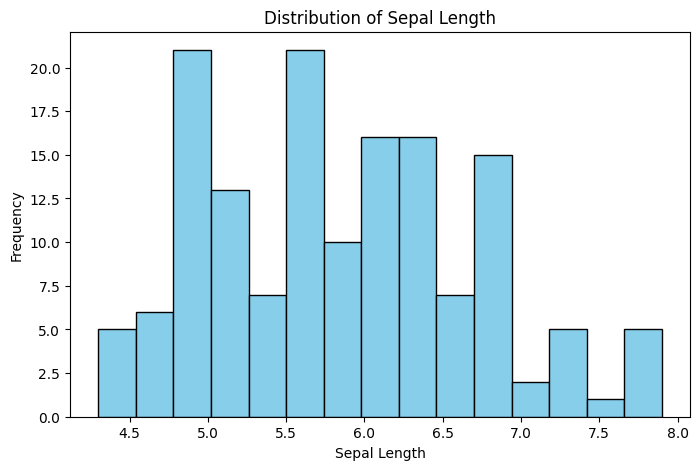

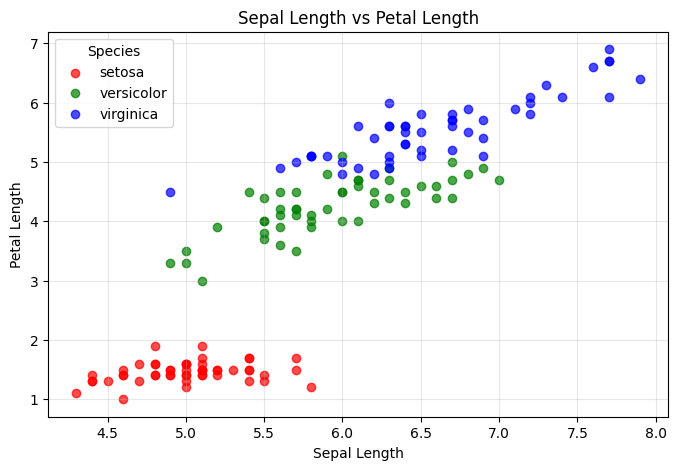

In [6]:
import matplotlib.pyplot as plt

# Histogram of sepal_length with 15 bins
plt.figure(figsize=(8, 5))
plt.hist(df["sepal_length"], bins=15, color="skyblue", edgecolor="black")
plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

# Scatter plot color-coded by species
colors = {
    "setosa": "red",
    "versicolor": "green",
    "virginica": "blue"
}

plt.figure(figsize=(8, 5))

for species, group in df.groupby("species", observed=True):
    plt.scatter(
        group["sepal_length"],
        group["petal_length"],
        color=colors[str(species)],
        label=species,
        alpha=0.7
    )

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend(title="Species")
plt.grid(alpha=0.3)
plt.show()

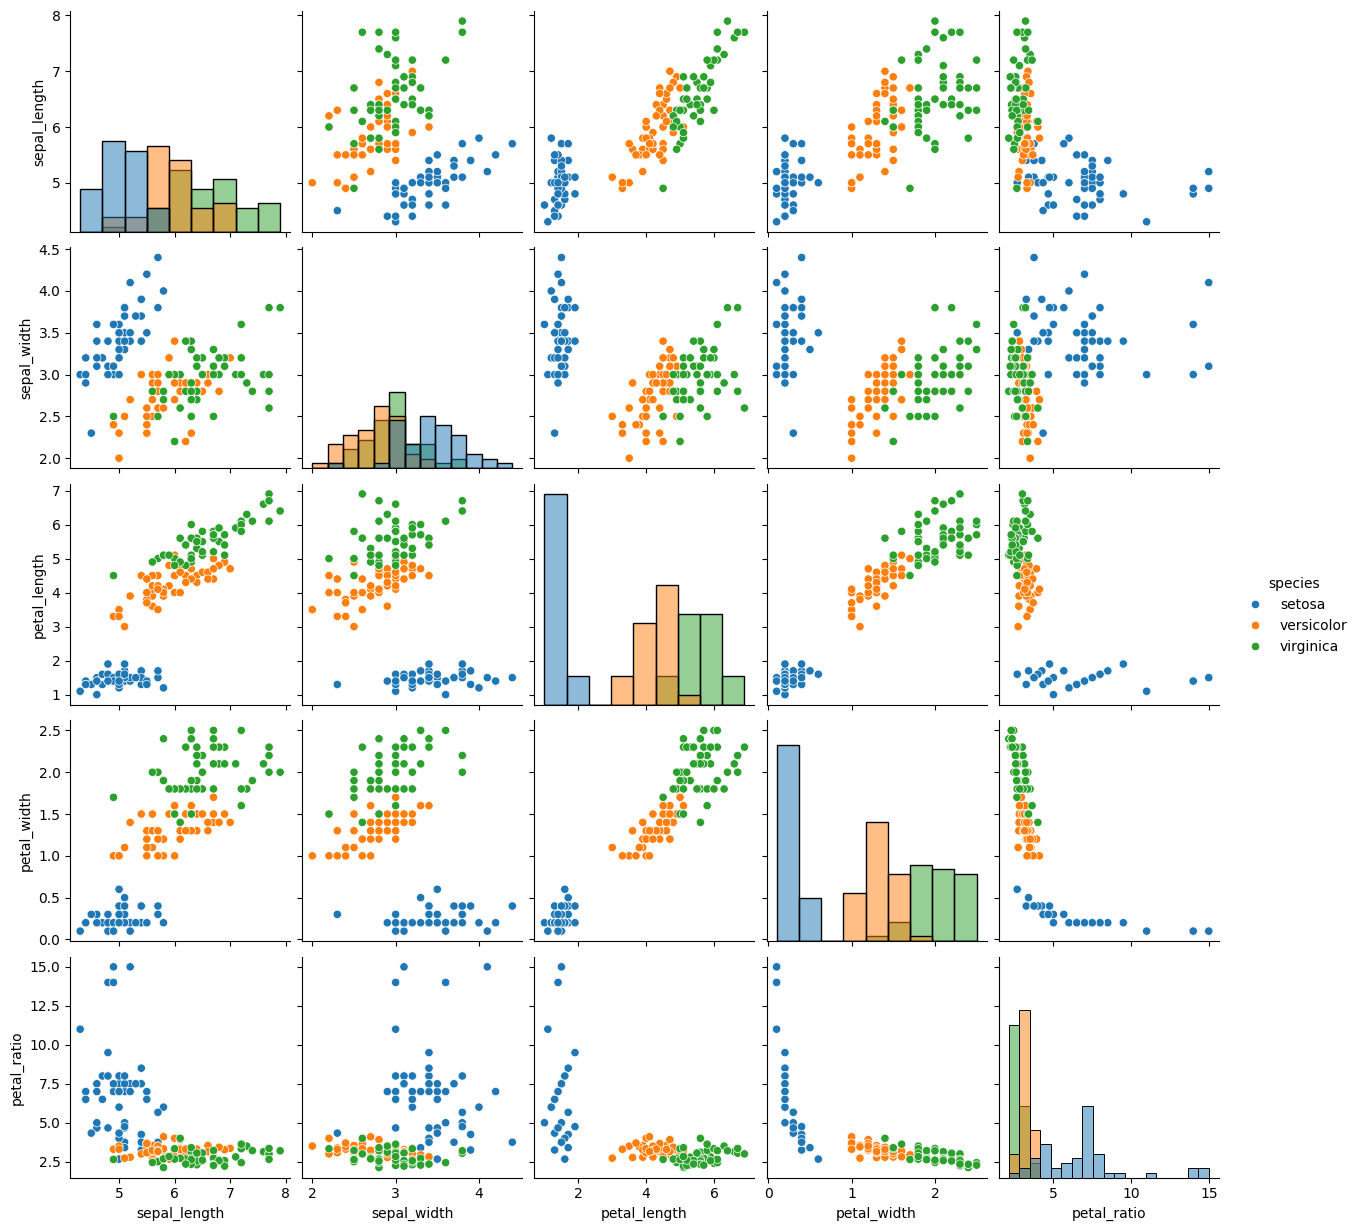

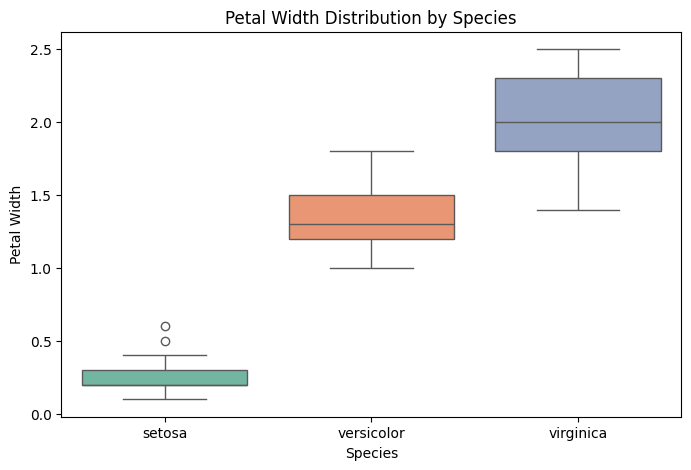

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot of the entire Iris dataset, colour-coded by species
sns.pairplot(df, hue="species", diag_kind="hist")
plt.show()

# Boxplot of petal_width distribution for each species
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="species",
    y="petal_width",
    hue="species",
    palette="Set2",
    legend=False
)

plt.title("Petal Width Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Petal Width")
plt.show()